In [1]:
suppressMessages({
    library(dplyr)
    library(Matrix)
    library(data.table)
    library(Seurat)
    library(ggplot2)
    library(RColorBrewer)
    library(ggalluvial)
    library(readxl)
    library(dplyr)
    library(reshape2)
    library(ggsci)
    library(clusterProfiler)
    library("org.Hs.eg.db")
    library(tidyr)
    library(patchwork)
    library(cowplot)
    library(harmony)
    library(ggpubr)
    library(ComplexHeatmap)
    library(stringr)  
    set.seed(123)
    })

In [2]:
cols<- unique(c("#FFFF00","#1CE6FF","#FF34FF","#FF4A46","#008941","#006FA6","#A30059","#FFE4E1","#0000A6","#B79762","#004D43","#8FB0FF","#997D87","#5A0007","#809693","#1B4400","#4FC601","#3B5DFF","#BA0900","#FF2F80","#6B7900","#00C2A0","#FFAA92","#FF90C9","#B903AA","#DDEFFF","#7B4F4B","#A1C299","#0AA6D8","#00A087FF","#4DBBD5FF","#E64B35FF","#3C5488FF","#0067A5","#63FFAC","#F38400","#A1CAF1", "#C2B280","#848482","#E68FAC", "#F99379", "#604E97","#F6A600", "#B3446C","#DCD300","#882D17", "#8DB600","#654522", "#E25822", "#2B3D26", "#191970","#000080","#6495ED","#1E90FF","#00BFFF","#00FFFF","#FF1493", "#FF00FF","#A020F0","#63B8FF","#008B8B","#54FF9F", "#00FF00","#76EE00","#FFF68F","Yellow1","Gold1", "DarkGoldenrod4","#FF6A6A","#FF8247","#FFA54F","#FF7F24", "#FF3030","#FFA500","#FF7F00","#FF7256","#FF6347", "#FF4500","#FF6EB4","#EE30A7","#8B008B","green",brewer.pal(9,"Set1")[-9],brewer.pal(12,"Paired")[c(3,4,6,8,10,12)],brewer.pal(8, "Dark2"),'#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b', '#e377c2', '#b5bd61', '#17becf' ,'#ffbb78','#ff9896')) ## unique 113

In [4]:
seuobj = readRDS("EX_CA3-4.rds")

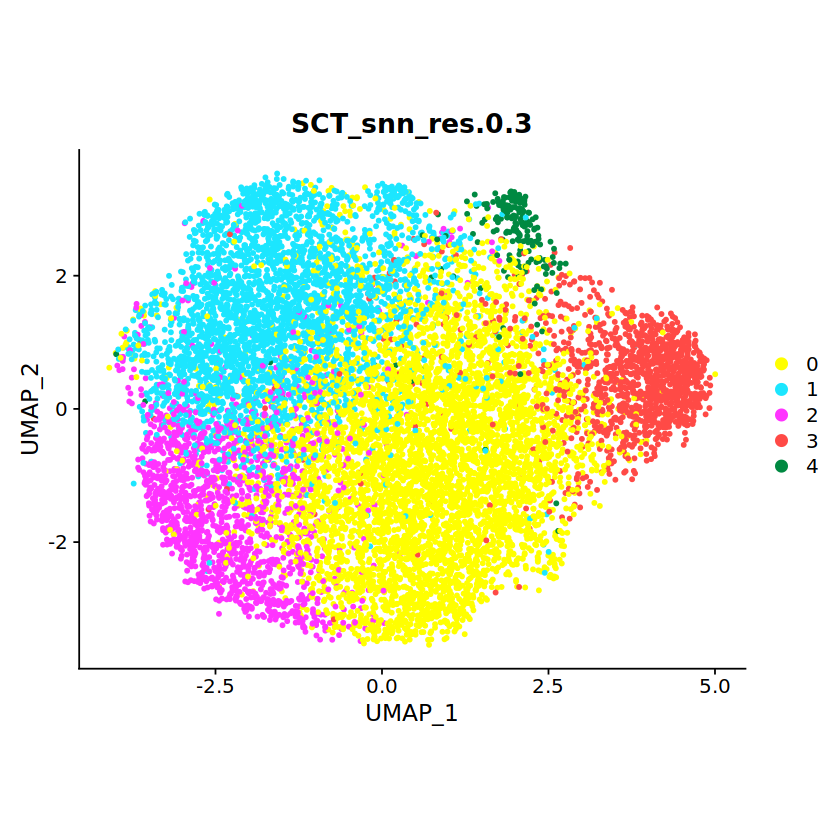

In [5]:
DimPlot(seuobj, reduction = "umap",group.by="SCT_snn_res.0.3", label = FALSE, pt.size = 1,cols=cols)+coord_fixed()  

In [7]:
##############============ select Go
#######################################################################
Select.Go = read.csv("select.Go.csv")

In [12]:
Clu4.Go = Select.Go %>% filter(Description %in% c('neuropeptide signaling pathway','peptide secretion'))

In [17]:
gene = list(c('ADCYAP1','PENK','CARTPT'))

In [19]:
seuobj.score=AddModuleScore(seuobj,features = gene,name = 'peptideScore')

In [64]:
options(repr.plot.width=10,repr.plot.height=6) 
data = seuobj.score@meta.data[,c("SCT_snn_res.0.3","peptideScore1")]

In [65]:
data[1:3,]

,SCT_snn_res.0.3,peptideScore1
,<fct>,<dbl>
HS22_257,1,-0.2603462
HS22_795,2,-0.1615168
HS22_1271,0,-0.3750543


In [66]:
colnames(data) =c("SCT_snn_res.0.3","score")

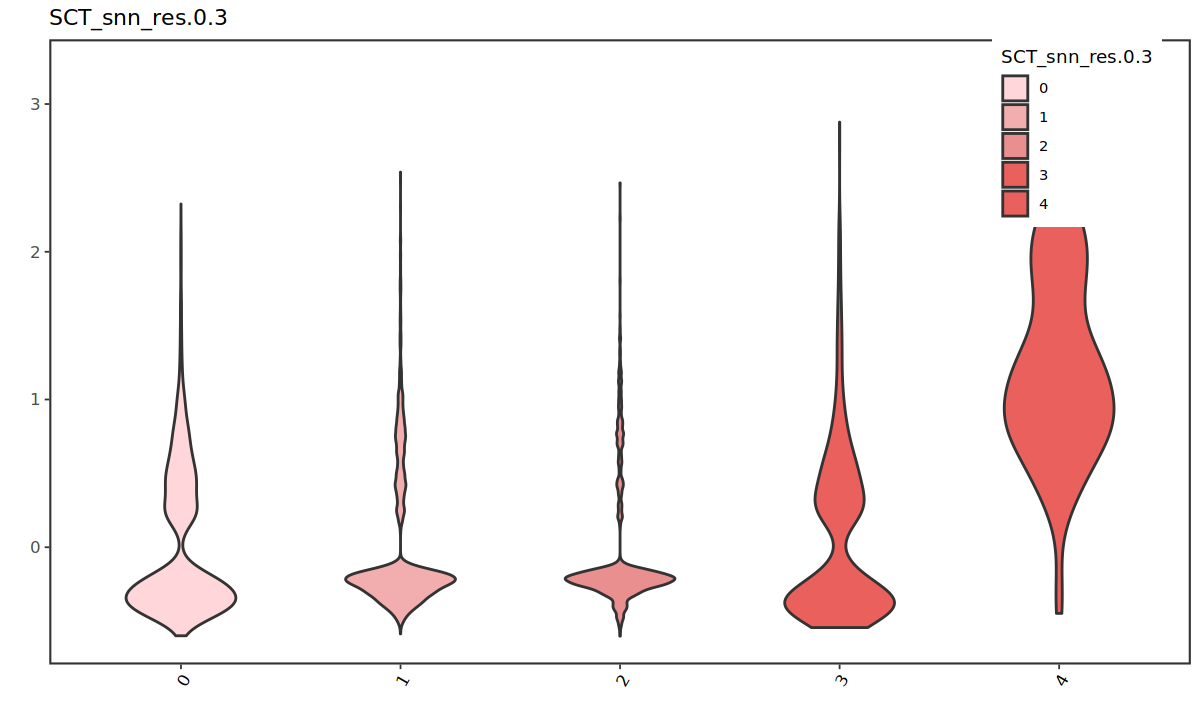

In [68]:
p = ggplot(data,aes(SCT_snn_res.0.3,score,fill=SCT_snn_res.0.3))+
      geom_violin(scale = "width",alpha=0.8,width=0.5,size=0.8)+ 
     xlab("")+  ylab("")+    theme_bw()+                                               
 scale_fill_manual(values = c("#ffcdd2","#ef9a9a","#e57373","#e53935","#e53935"))+  
      theme(panel.grid.major=element_blank(),
        panel.grid.minor=element_blank(),
        panel.border=element_rect(size=1.2),                 
        axis.text.x = element_text(angle=60,size=10,vjust = 1,hjust =1,color = "black"),                                                   
        axis.text.y = element_text(size =10),
        legend.position = c(0.9,0.85) )+ggtitle("SCT_snn_res.0.3")
    print(p)

In [69]:
ggsave(plot=p,"group.vlnplot.pdf",width=5)

Saving 5 x 6.67 in image
